In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.passes.synthesis.high_level_synthesis import HLSConfig
import numpy as np

# ========== 模型参数 ==========
N = 5               # Qubit 数量
J = 1.0             # ZZ 耦合
h = 1.0             # 横场强度
trotter_step = 0.1  # 每步演化时间
n_time = 10         # 演化步数
shots = 2000        # 测量采样次数

# ========== 构造 TFIM 哈密顿量 ==========
pauli_list = []
coeffs = []

# ZZ 相互作用项：-J * Z_i Z_{i+1}
for i in range(N - 1):
    pauli_str = ['I'] * N
    pauli_str[i] = 'Z'
    pauli_str[i + 1] = 'Z'
    pauli_list.append(''.join(pauli_str))
    coeffs.append(-J)

# 横场项：-h * X_i
for i in range(N):
    pauli_str = ['I'] * N
    pauli_str[i] = 'X'
    pauli_list.append(''.join(pauli_str))
    coeffs.append(-h)

# SparsePauliOp 哈密顿量
Hamil = SparsePauliOp.from_list(list(zip(pauli_list, coeffs)))

# ========== 配置 AerSimulator 并编译 ==========
sim = AerSimulator()





In [2]:
# compiled.draw()

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from itertools import product
import numpy as np

evolution_op = PauliEvolutionGate(Hamil, time=trotter_step)
X_sum = SparsePauliOp(
    ['XIIII', 'IXIII', 'IIXII', 'IIIXI', 'IIIIX'],
    coeffs=[1] * N
)

results = {}

# 遍历所有基态
for bits in product([0, 1], repeat=N):
    print(bits)
    basis_label = ''.join(map(str, bits))  # 如 '00001'
    results[basis_label] = []

    for step in range(1, n_time + 1):
        qc = QuantumCircuit(N)
        
        # 准备初始态
        for i, b in enumerate(reversed(bits)):
            if b == 1:
                qc.x(i)
        
        # 演化 step 次
        for _ in range(step):
            qc.append(evolution_op, range(N))
        
        # X -> Z basis
        for i in range(N):
            qc.h(i)
        qc.measure_all()

        compiled = transpile(qc, sim)
        result = sim.run(compiled, shots=shots).result()
        counts = result.get_counts()

        # 估计 X_sum
        expval_sampled = 0
        for bitstring, count in counts.items():
            x_val = sum([1 if bit == '0' else -1 for bit in bitstring])
            expval_sampled += x_val * count
        expval_sampled /= shots

        results[basis_label].append(expval_sampled)

# 可视化或打印其中一组
# for k, v in results.items():
#     print(f"Basis {k} -> ⟨X_sum⟩ per step: {v}")


(0, 0, 0, 0, 0)
(0, 0, 0, 0, 1)
(0, 0, 0, 1, 0)
(0, 0, 0, 1, 1)
(0, 0, 1, 0, 0)
(0, 0, 1, 0, 1)
(0, 0, 1, 1, 0)
(0, 0, 1, 1, 1)
(0, 1, 0, 0, 0)
(0, 1, 0, 0, 1)
(0, 1, 0, 1, 0)
(0, 1, 0, 1, 1)
(0, 1, 1, 0, 0)
(0, 1, 1, 0, 1)
(0, 1, 1, 1, 0)
(0, 1, 1, 1, 1)
(1, 0, 0, 0, 0)
(1, 0, 0, 0, 1)
(1, 0, 0, 1, 0)
(1, 0, 0, 1, 1)
(1, 0, 1, 0, 0)
(1, 0, 1, 0, 1)
(1, 0, 1, 1, 0)
(1, 0, 1, 1, 1)
(1, 1, 0, 0, 0)
(1, 1, 0, 0, 1)
(1, 1, 0, 1, 0)
(1, 1, 0, 1, 1)
(1, 1, 1, 0, 0)
(1, 1, 1, 0, 1)
(1, 1, 1, 1, 0)
(1, 1, 1, 1, 1)


In [5]:
sorted_basis = sorted(results.keys())
data = np.array([results[basis] for basis in sorted_basis])

In [6]:
np.sum(data, axis=0)/32

array([ 0.00765625,  0.016     , -0.00690625,  0.01021875,  0.01684375,
        0.004     ,  0.00315625, -0.00309375,  0.00221875,  0.00084375])

In [7]:
from functools import reduce
Z = np.array([[1, 0], [0, -1]])
I = np.eye(2)

# 按从左到右张量积
ZZIII = reduce(np.kron, [Z, Z, I, I, I])

In [8]:
data_load = np.load("Coff_O_Data_5qbits.npz")
Coff_t = data_load['coff_trunc_t']
time_list= data_load['t_list']
ini_state= data_load['ini_state']
name_trunc=data_load['name_trunc']
X_sum=data_load['X_sum']

In [9]:
print(time_list[0:10])
print(name_trunc.tolist().index('ZZIII'))

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
24


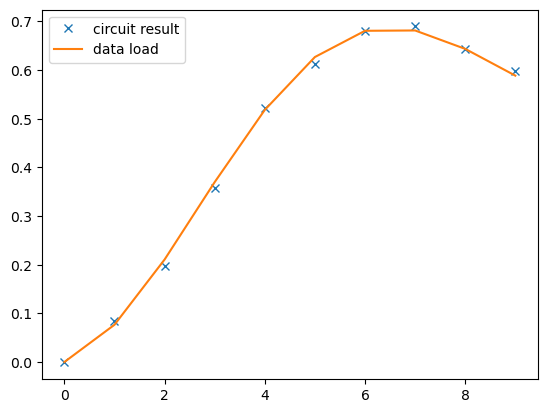

In [10]:
import matplotlib.pyplot as plt

plt.plot(np.diag(ZZIII) @ data / 32, 'x', label='circuit result')
plt.plot(np.real(Coff_t[1:1+10, 24]), label='data load')
plt.legend()
plt.show()

In [ ]:

# evolution_op = PauliEvolutionGate(Hamil, time=trotter_step)
# X_sum = SparsePauliOp(
#     ['XIIII', 'IXIII', 'IIXII', 'IIIXI', 'IIIIX'],
#     coeffs=[1] * N
# )

# expval_list = []

# for step in range(1, n_time + 1):
#     # 构造测量电路
#     qc_step = QuantumCircuit(N)
#     for _ in range(step):
#         qc_step.append(evolution_op, range(N))
    
#     # 变换到 Z 基测量
#     for i in range(N):
#         qc_step.h(i)
#     qc_step.measure_all()
    
#     compiled = transpile(qc_step, sim)
#     result = sim.run(compiled, shots=shots).result()
#     counts = result.get_counts()

#     # 估计 X_sum
#     expval_sampled = 0
#     for bitstring, count in counts.items():
#         x_val = sum([1 if bit == '0' else -1 for bit in bitstring])
#         expval_sampled += x_val * count
#     expval_sampled /= shots

#     expval_list.append(expval_sampled)
#     # print(f"⟨X_sum⟩ after step {step} =", expval_sampled)
